# HumanForYou — Exploration des données (EDA)

**Objectif :** Comprendre la structure des données, identifier les problèmes de qualité (valeurs manquantes, colonnes inutiles, déséquilibre des classes) et poser les bases du preprocessing.

**Sources de données utilisées :**
- `general_data.csv` — données RH générales
- `employee_survey_data.csv` — enquête satisfaction employé
- `manager_survey_data.csv` — évaluation du manager (JobInvolvement, PerformanceRating)
- `in_time.csv` / `out_time.csv` — horaires de badgeage 2015

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RAW = '../data/raw/'

---
## 1. Chargement des données

In [2]:
general  = pd.read_csv(RAW + 'general_data.csv')
survey   = pd.read_csv(RAW + 'employee_survey_data.csv')
manager  = pd.read_csv(RAW + 'manager_survey_data.csv')
in_time  = pd.read_csv(RAW + 'in_time.csv', index_col=0)
out_time = pd.read_csv(RAW + 'out_time.csv', index_col=0)

print(f"general_data        : {general.shape}")
print(f"employee_survey     : {survey.shape}")
print(f"manager_survey      : {manager.shape}")
print(f"in_time             : {in_time.shape}")
print(f"out_time            : {out_time.shape}")

general_data        : (4410, 24)
employee_survey     : (4410, 4)
manager_survey      : (4410, 3)
in_time             : (4410, 261)
out_time            : (4410, 261)


---
## 2. Aperçu général

In [3]:
general.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4


In [4]:
general.info()

<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   str    
 2   BusinessTravel           4410 non-null   str    
 3   Department               4410 non-null   str    
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   str    
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   str    
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   str    
 12  MaritalStatus            4410 non-null   str    
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked       4391 non-n

In [5]:
general.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,4410.0,NaN,NaN,NaN,36.92381,9.133301,18.0,30.0,36.0,43.0,60.0
Attrition,4410,2,No,3699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,4410,3,Travel_Rarely,3129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,4410,3,Research & Development,2883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,4410.0,NaN,NaN,NaN,9.192517,8.105026,1.0,2.0,7.0,14.0,29.0
Education,4410.0,NaN,NaN,NaN,2.912925,1.023933,1.0,2.0,3.0,4.0,5.0
EducationField,4410,6,Life Sciences,1818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,4410.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeID,4410.0,NaN,NaN,NaN,2205.5,1273.201673,1.0,1103.25,2205.5,3307.75,4410.0
Gender,4410,2,Male,2646,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Variable cible : Attrition

In [6]:
attr_counts = general['Attrition'].value_counts()
attr_pct    = general['Attrition'].value_counts(normalize=True) * 100

print(attr_counts)
print()
print(attr_pct.round(1).astype(str) + ' %')

Attrition
No     3699
Yes     711
Name: count, dtype: int64

Attrition
No     83.9 %
Yes    16.1 %
Name: proportion, dtype: str


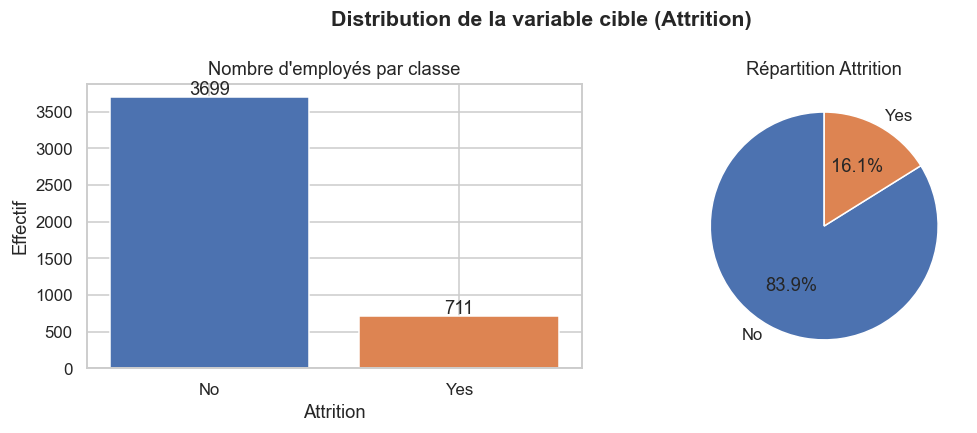


=> Déséquilibre : 83.9% Non / 16.1% Oui


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(attr_counts.index, attr_counts.values, color=['#4C72B0', '#DD8452'])
for i, (label, val) in enumerate(zip(attr_counts.index, attr_counts.values)):
    axes[0].text(i, val + 30, str(val), ha='center', fontsize=12)
axes[0].set_title('Nombre d\'employés par classe')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Effectif')

axes[1].pie(attr_counts.values, labels=attr_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Répartition Attrition')

plt.suptitle('Distribution de la variable cible (Attrition)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/attrition_distribution.png', bbox_inches='tight')
plt.show()

print(f"\n=> Déséquilibre : {attr_pct['No']:.1f}% Non / {attr_pct['Yes']:.1f}% Oui")

---
## 4. Identification des colonnes inutiles

In [8]:
nunique = general.nunique()
constant_cols = nunique[nunique == 1].index.tolist()
print("Colonnes constantes (1 seule valeur unique) :", constant_cols)

for col in constant_cols:
    print(f"  {col} → {general[col].unique()}")

Colonnes constantes (1 seule valeur unique) : ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount → [1]
  Over18 → <StringArray>
['Y']
Length: 1, dtype: str
  StandardHours → [8]


> **Décision** : `EmployeeCount`, `Over18` et `StandardHours` ont une seule valeur pour tous les employés → elles seront supprimées lors du preprocessing.

---
## 5. Valeurs manquantes

In [9]:
def missing_summary(df, name):
    na = df.isna().sum()
    na = na[na > 0]
    if na.empty:
        print(f"{name} : aucune valeur manquante")
    else:
        pct = (na / len(df) * 100).round(2)
        print(f"\n{name} — valeurs manquantes :")
        for col in na.index:
            print(f"  {col:35s} {na[col]:4d} ({pct[col]:.2f}%)")

missing_summary(general, 'general_data')
missing_summary(survey,  'employee_survey')
missing_summary(manager, 'manager_survey')


general_data — valeurs manquantes :
  NumCompaniesWorked                    19 (0.43%)
  TotalWorkingYears                      9 (0.20%)

employee_survey — valeurs manquantes :
  EnvironmentSatisfaction               25 (0.57%)
  JobSatisfaction                       20 (0.45%)
  WorkLifeBalance                       38 (0.86%)
manager_survey : aucune valeur manquante


---
## 6. Distribution des variables numériques

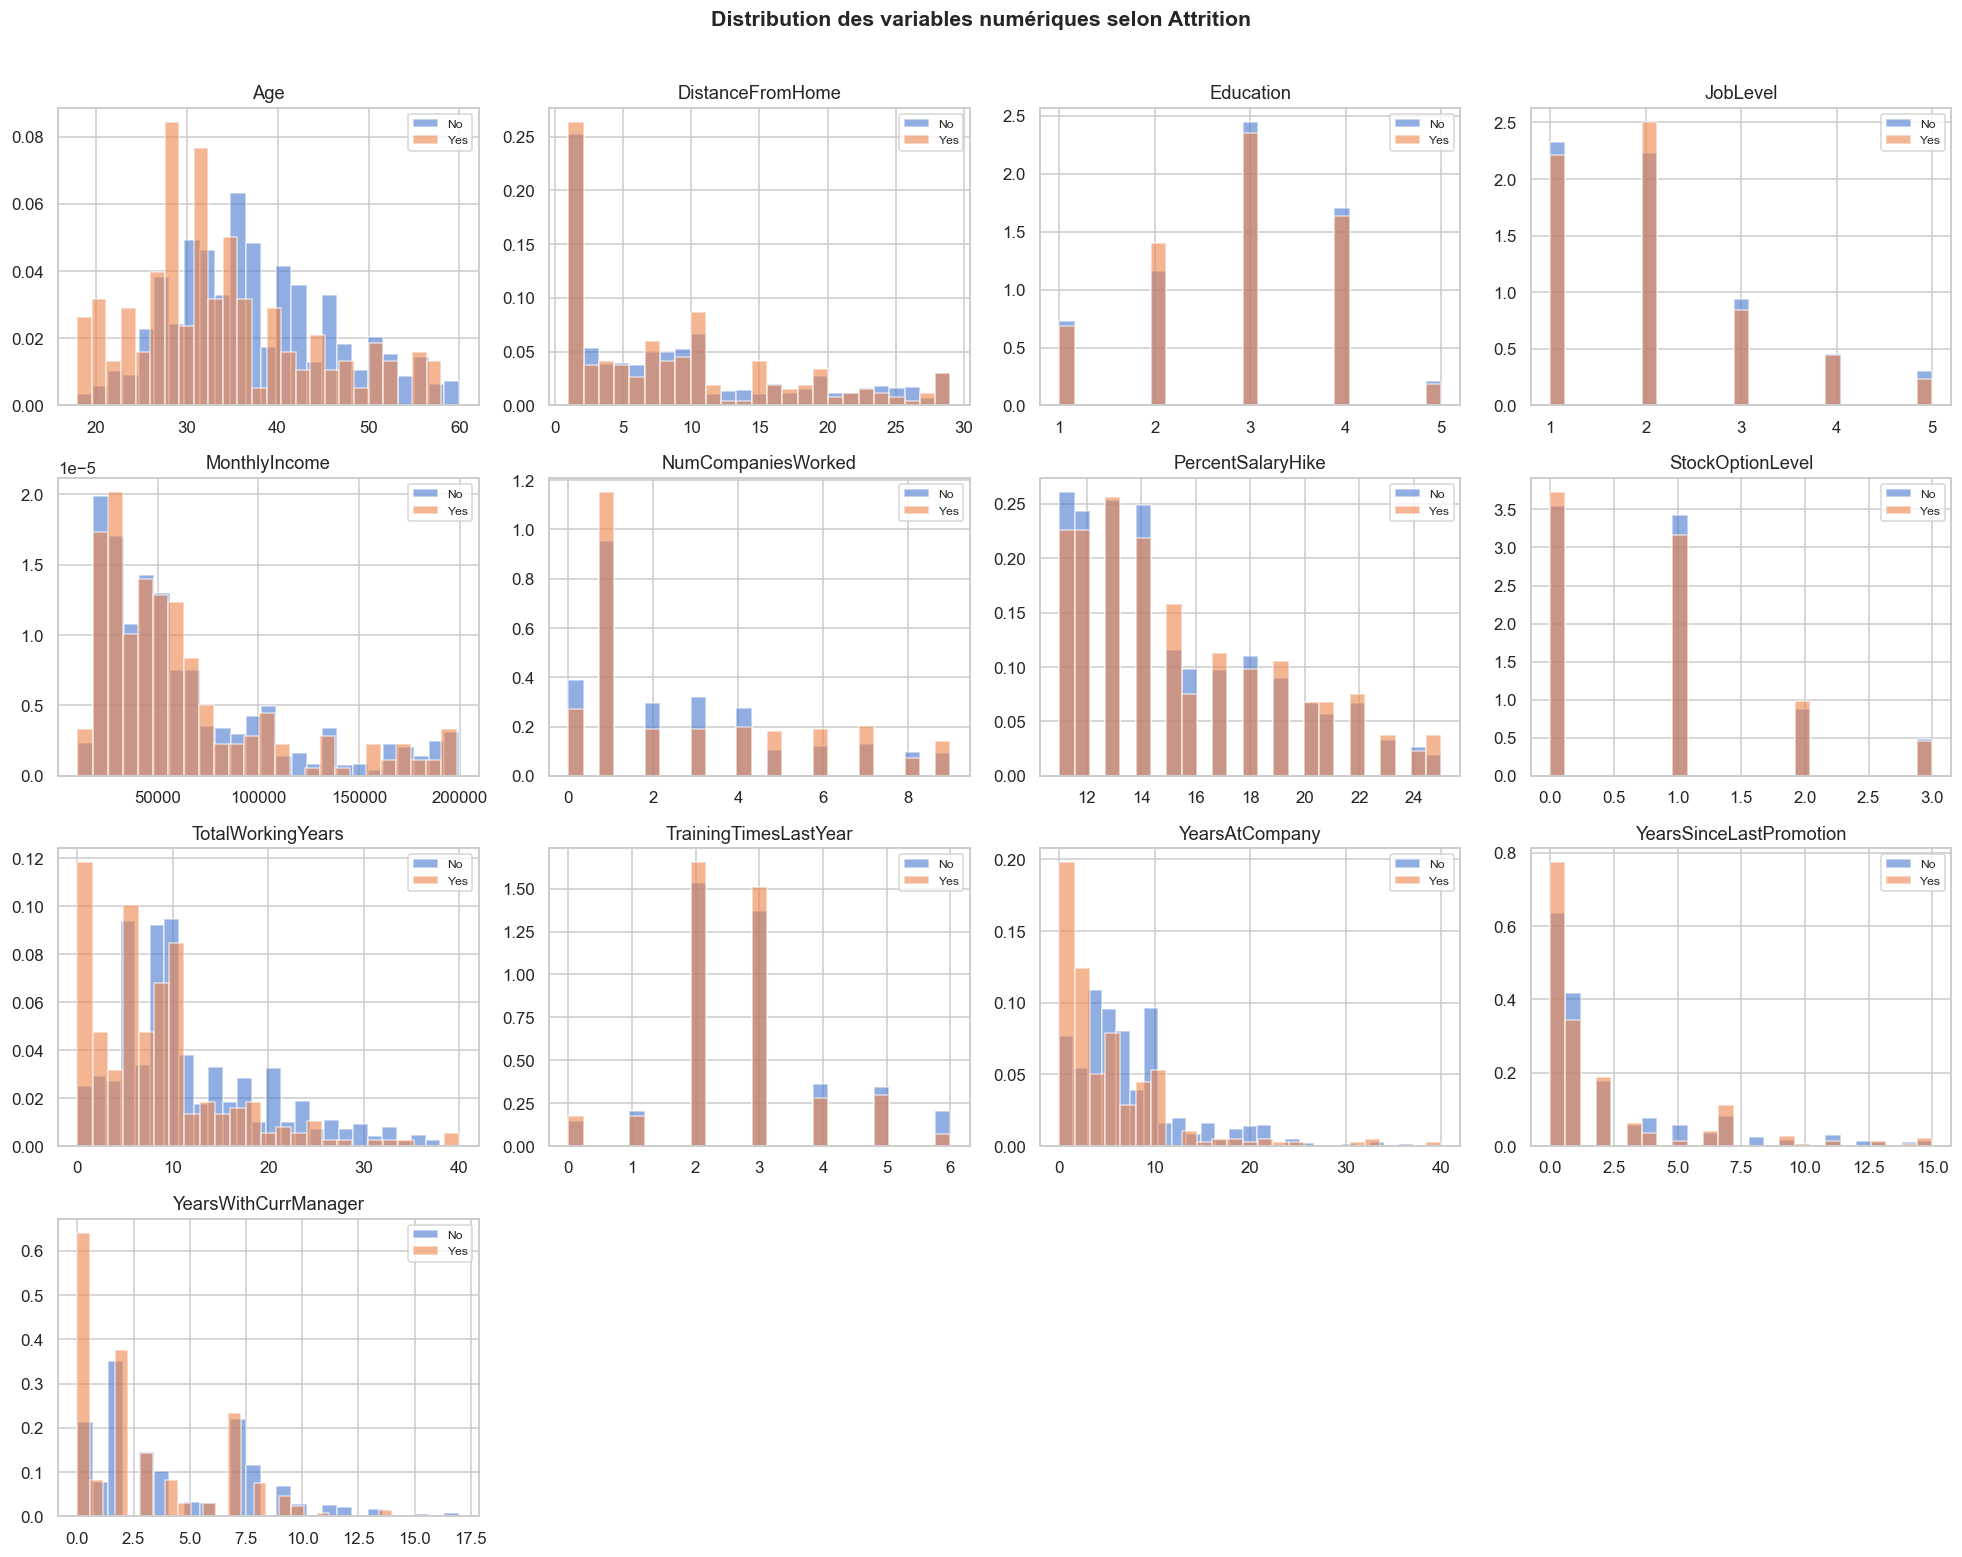

In [10]:
num_cols = general.select_dtypes(include='number').columns.drop(['EmployeeID', 'EmployeeCount', 'StandardHours'])

n_cols = 4
n_rows = -(-len(num_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, grp in general.groupby('Attrition'):
        axes[i].hist(grp[col].dropna(), bins=25, alpha=0.6, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables numériques selon Attrition', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/numeric_distributions.png', bbox_inches='tight')
plt.show()

---
## 7. Distribution des variables catégorielles

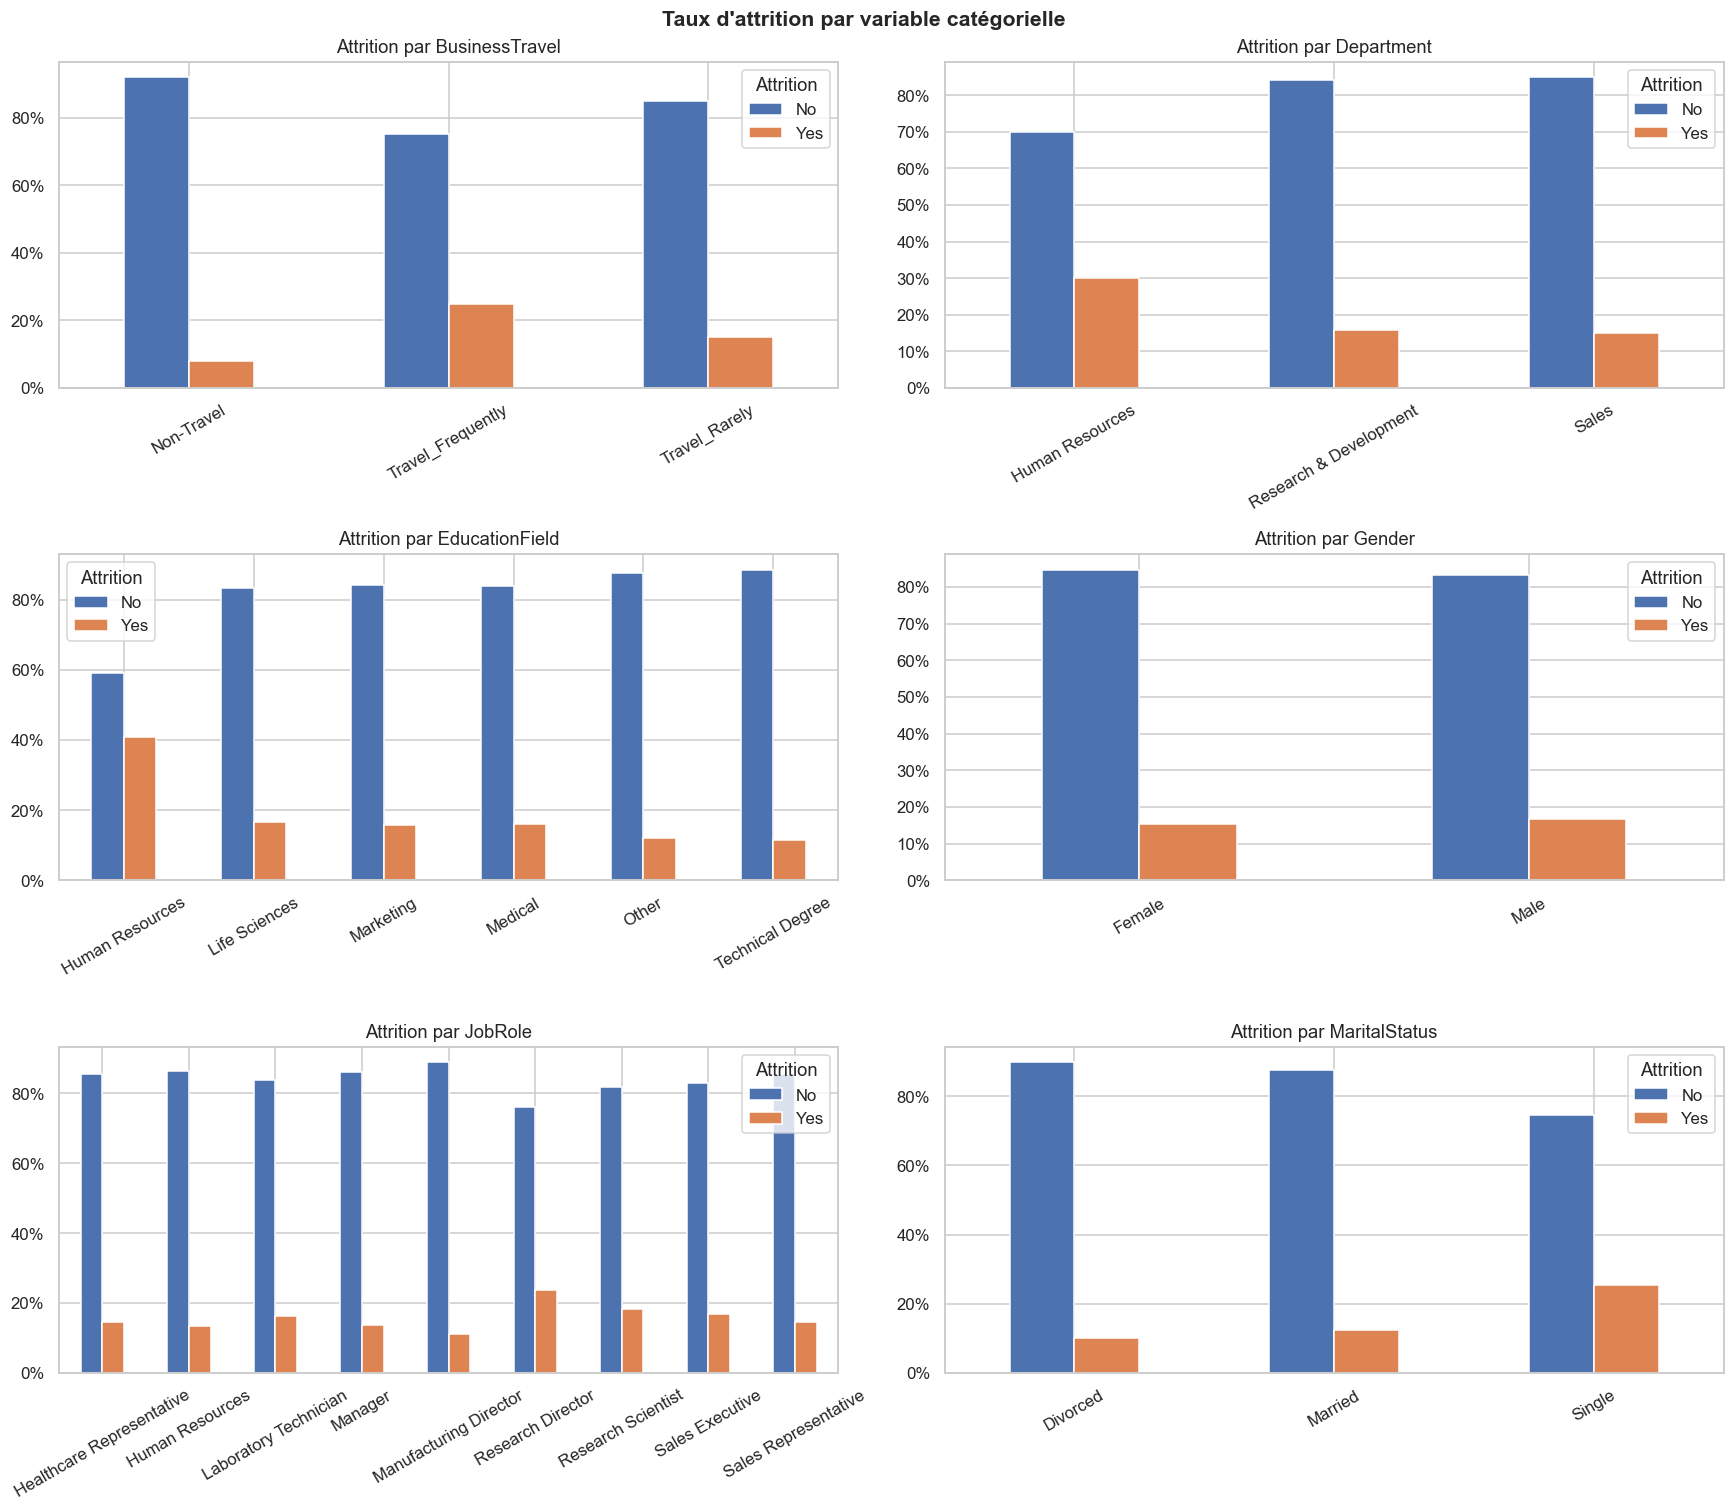

In [11]:
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    tbl = general.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    tbl_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(f'Attrition par {col}')
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Attrition')

plt.suptitle('Taux d\'attrition par variable catégorielle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/categorical_attrition.png', bbox_inches='tight')
plt.show()

---
## 8. Analyse des scores de satisfaction (enquête employés)

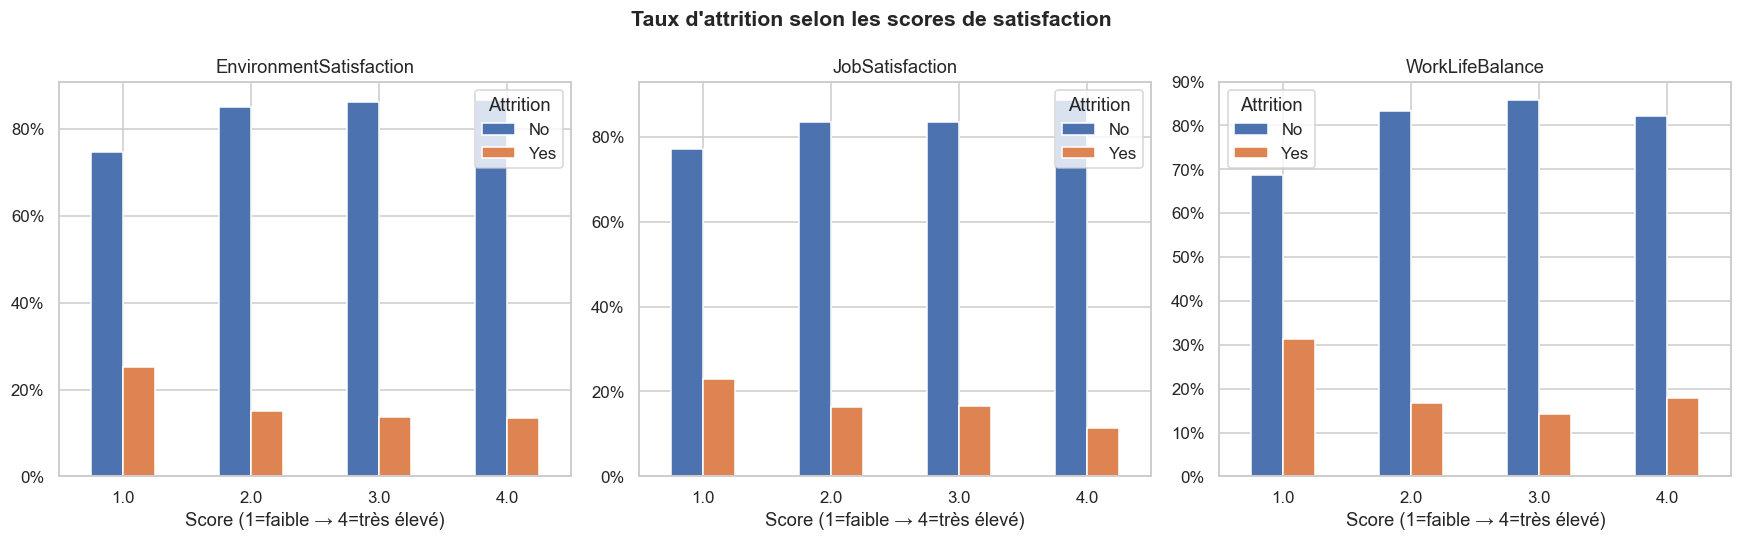

In [12]:
survey_merged = survey.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')

sat_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(sat_cols):
    tbl = survey_merged.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    tbl_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(col)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Attrition')
    axes[i].set_xlabel('Score (1=faible → 4=très élevé)')

plt.suptitle('Taux d\'attrition selon les scores de satisfaction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/satisfaction_attrition.png', bbox_inches='tight')
plt.show()

---
## 9. Analyse de l'évaluation manager (manager_survey_data)

Ce fichier contient deux variables issues de l'évaluation faite par le manager en février 2015 :
- `JobInvolvement` : implication dans le travail (1 = faible → 4 = très importante)
- `PerformanceRating` : performance annuelle (1 = faible → 4 = au-delà des attentes)

> Note : `PerformanceRating` ne contient que les valeurs 3 et 4 — tous les employés sont évalués "Excellent" ou "Au-delà des attentes". Cette variable est peu discriminante mais on la conserve.

Valeurs uniques :
  JobInvolvement   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  PerformanceRating: [np.int64(3), np.int64(4)]

NA : {'EmployeeID': 0, 'JobInvolvement': 0, 'PerformanceRating': 0}


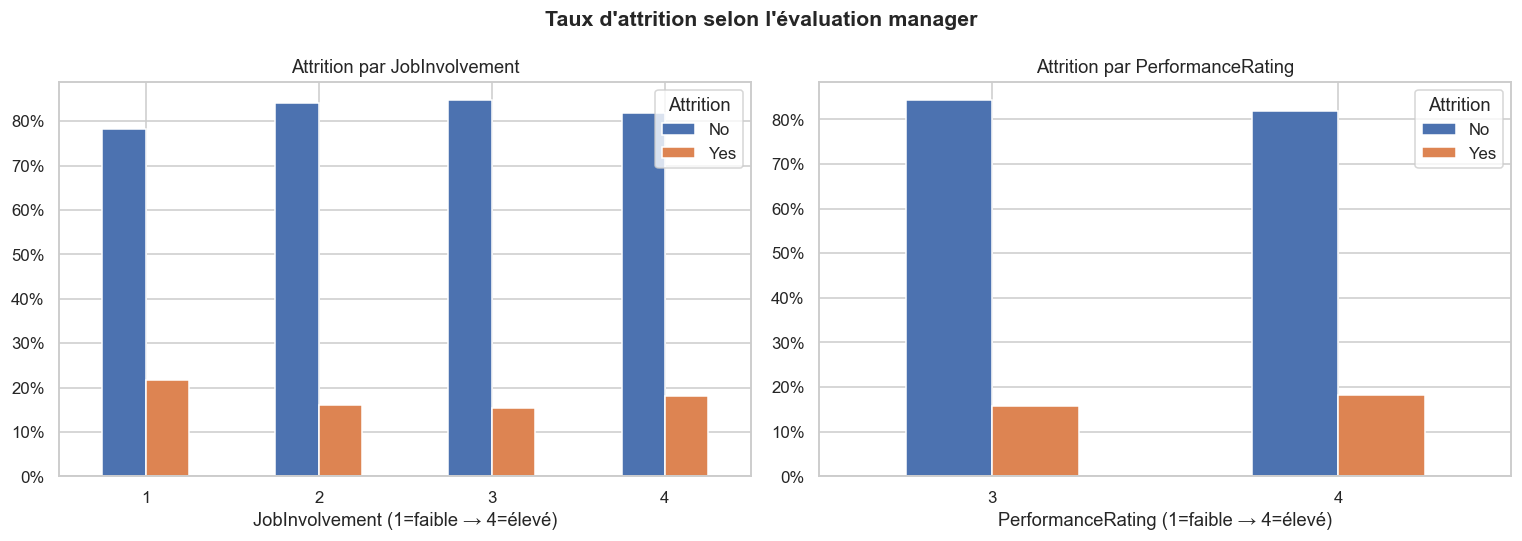


Taux d'attrition par JobInvolvement :
JobInvolvement
1    21.7
2    16.0
3    15.3
4    18.1


In [13]:
manager_merged = manager.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')

print("Valeurs uniques :")
print(f"  JobInvolvement   : {sorted(manager['JobInvolvement'].unique())}")
print(f"  PerformanceRating: {sorted(manager['PerformanceRating'].unique())}")
print(f"\nNA : {manager.isna().sum().to_dict()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['JobInvolvement', 'PerformanceRating']):
    tbl = manager_merged.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    tbl_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(f'Attrition par {col}')
    axes[i].set_xlabel(f'{col} (1=faible → 4=élevé)')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Attrition')

plt.suptitle("Taux d'attrition selon l'évaluation manager", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/manager_survey_attrition.png', bbox_inches='tight')
plt.show()

print("\nTaux d'attrition par JobInvolvement :")
print(manager_merged.groupby('JobInvolvement')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100).round(1).to_string())

---
## 10. Matrice de corrélation (variables numériques)

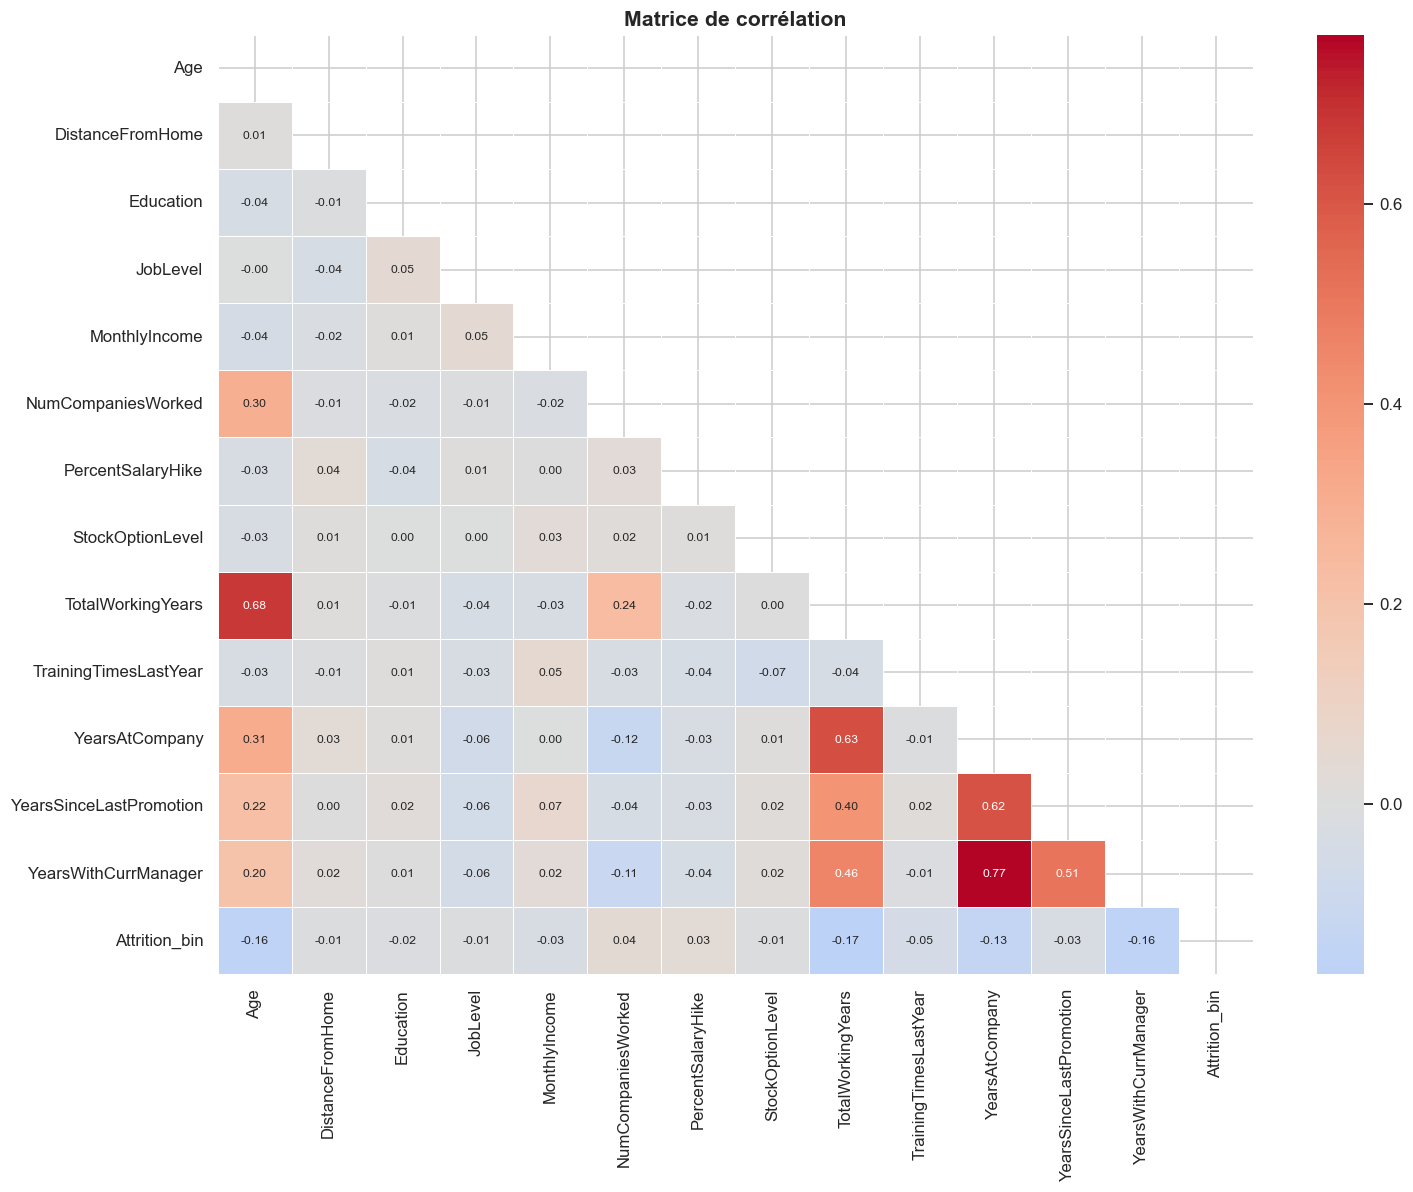

In [14]:
gen_corr = general.copy()
gen_corr['Attrition_bin'] = (gen_corr['Attrition'] == 'Yes').astype(int)

num_corr_cols = list(num_cols) + ['Attrition_bin']
corr_matrix = gen_corr[num_corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matrice de corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_matrix.png', bbox_inches='tight')
plt.show()

In [15]:
corr_with_target = corr_matrix['Attrition_bin'].drop('Attrition_bin').sort_values(key=abs, ascending=False)
print("Corrélations avec Attrition (triées par valeur absolue) :")
print(corr_with_target.round(3).to_string())

Corrélations avec Attrition (triées par valeur absolue) :
TotalWorkingYears         -0.170
Age                       -0.159
YearsWithCurrManager      -0.156
YearsAtCompany            -0.134
TrainingTimesLastYear     -0.049
NumCompaniesWorked         0.042
YearsSinceLastPromotion   -0.033
PercentSalaryHike          0.033
MonthlyIncome             -0.031
Education                 -0.015
JobLevel                  -0.010
DistanceFromHome          -0.010
StockOptionLevel          -0.007


---
## 11. Exploration des données de badgeage

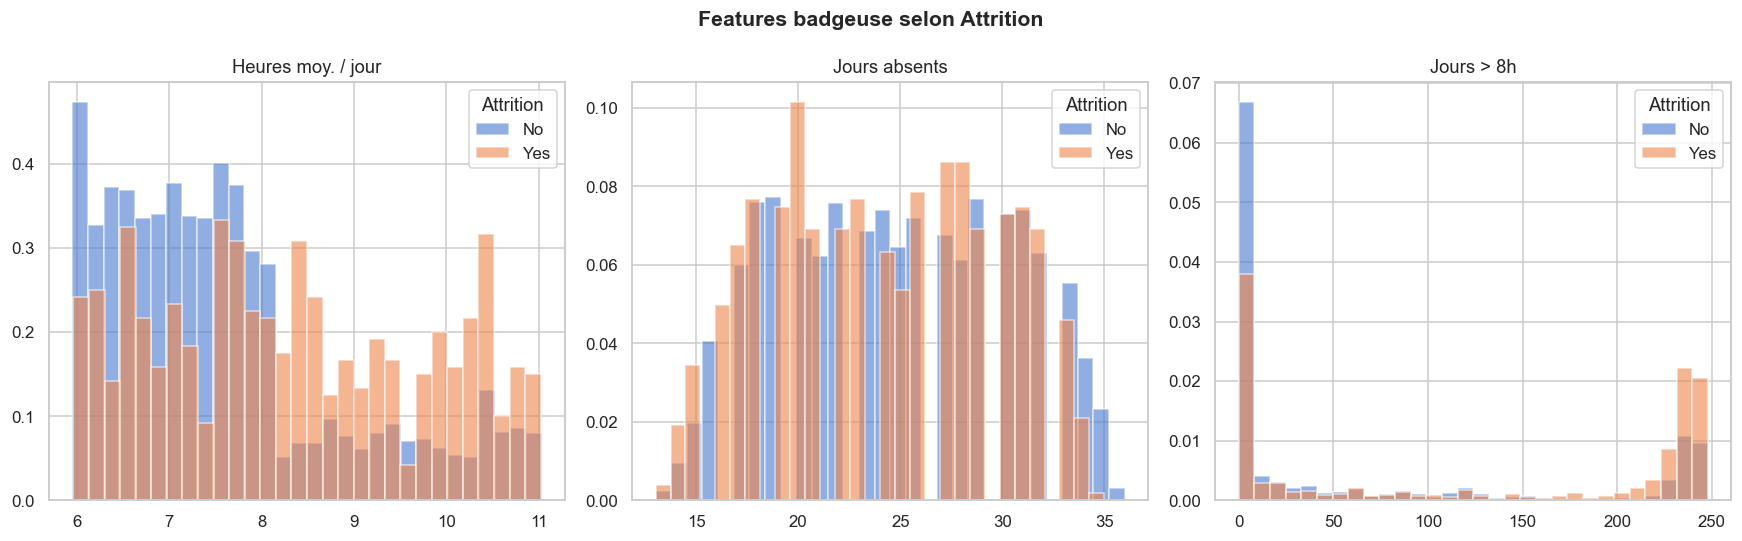

In [16]:
in_dt  = in_time.apply(pd.to_datetime, errors='coerce')
out_dt = out_time.apply(pd.to_datetime, errors='coerce')

work_hours = (out_dt - in_dt).apply(lambda s: s.dt.total_seconds() / 3600)

badge_features = pd.DataFrame()
badge_features['EmployeeID']       = general['EmployeeID'].values
badge_features['avg_hours_per_day'] = work_hours.mean(axis=1).values
badge_features['std_hours_per_day'] = work_hours.std(axis=1).values
badge_features['days_absent']       = work_hours.isna().sum(axis=1).values
badge_features['days_over_8h']      = (work_hours > 8).sum(axis=1).values
badge_features['avg_arrival_hour']  = in_dt.apply(
    lambda col: col.dt.hour + col.dt.minute / 60).mean(axis=1).values

badge_merged = badge_features.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
feat_badge   = ['avg_hours_per_day', 'days_absent', 'days_over_8h']
labels_badge = ['Heures moy. / jour', 'Jours absents', 'Jours > 8h']

for i, (col, label) in enumerate(zip(feat_badge, labels_badge)):
    for attrition, grp in badge_merged.groupby('Attrition'):
        axes[i].hist(grp[col].dropna(), bins=30, alpha=0.6, label=attrition, density=True)
    axes[i].set_title(label)
    axes[i].legend(title='Attrition')

plt.suptitle('Features badgeuse selon Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/badge_features_attrition.png', bbox_inches='tight')
plt.show()

---
## 12. Résumé des décisions issues de l'EDA

| # | Sujet | Décision |
|---|-------|----------|
| 1 | Colonnes constantes | Supprimer `EmployeeCount`, `Over18`, `StandardHours` |
| 2 | Valeurs manquantes numériques | Imputation par la **médiane** |
| 3 | Valeurs manquantes survey | Imputation par la **médiane** (non-répondants conservés) |
| 4 | Déséquilibre des classes | 84% / 16% → gérer avec `class_weight='balanced'` |
| 5 | Features badgeuse | Extraire : heures moy/jour, variabilité, jours absents, jours > 8h, heure arrivée |
| 6 | Encodage catégoriel | `LabelEncoder` ou `OneHotEncoder` selon le modèle |
| 7 | manager_survey | `JobInvolvement` et `PerformanceRating` intégrés — `PerformanceRating` peu discriminant (valeurs 3 et 4 seulement) mais conservé |

**Prochaine étape : preprocessing → notebook 02**